In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf, adfuller
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from mpl_toolkits.mplot3d import Axes3D

# 1. Przypadek jednowymiarowy

### **Wczytanie danych**

In [2]:
start_date = '2018-01-01'
end_date = '2026-01-01'

disney_ticker = 'DIS'
eurusd_ticker = 'EURUSD=X'
xly_ticker = 'XLY'

all_data = yf.download(
    tickers=[disney_ticker, eurusd_ticker, xly_ticker],
    start=start_date,
    end=end_date,
    progress=False
)["Close"]

all_data = all_data.rename(columns={
    disney_ticker: "disney",
    eurusd_ticker: "fx",
    xly_ticker: "consumer"
})

all_data = all_data.dropna()

C:\Users\Ja\AppData\Local\Temp\ipykernel_14068\2984865492.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  all_data = yf.download(


In [3]:
all_data.head()

Ticker,disney,fx,consumer
Date,,,
2018-01-02,106.224525,1.201158,46.275242
2018-01-03,106.680588,1.206345,46.487690
2018-01-04,106.633087,1.201043,46.640125
2018-01-05,106.053505,1.206884,47.009613
2018-01-08,104.533302,1.203746,47.065037


In [4]:
all_data.tail()

Ticker,disney,fx,consumer
Date,,,
2025-12-24,114.480003,1.179551,122.344231
2025-12-26,113.559998,1.178536,121.805321
2025-12-29,114.190002,1.177274,120.607719
2025-12-30,114.790001,1.177288,120.118706
2025-12-31,113.769997,1.174729,119.170609


Analiza obejmuje dane dzienne z okresu od 2 stycznia 2018 do 31 grudnia 2025 i dotyczy cen zamknięcia akcji oraz wybranych zmiennych rynkowych.

### Przygotowanie danych do analizy

In [5]:
date = all_data.index
Date = pd.to_datetime(date)

Disney = all_data["disney"]
Currency = all_data["fx"]
Consumer = all_data["consumer"]

### Weryfikacja braków danych

In [6]:
print(all_data.isnull().sum())

Ticker
disney      0
fx          0
consumer    0
dtype: int64


wykres kursu EUR/USD,
wykres ceny akcji Walt Disney,
wykres ceny ETF XLY

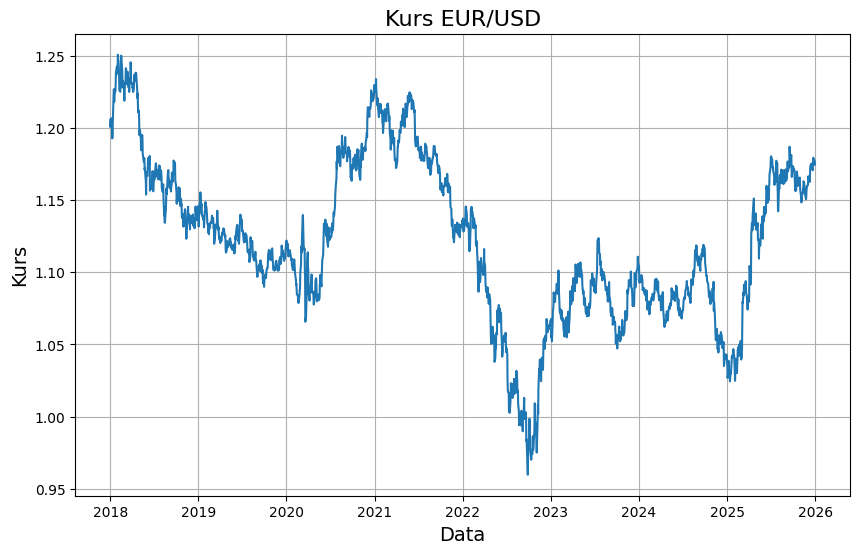

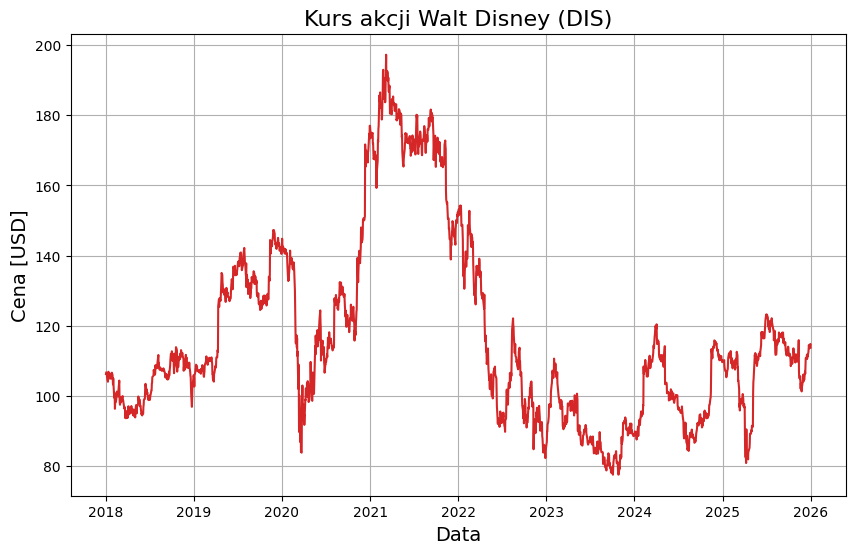

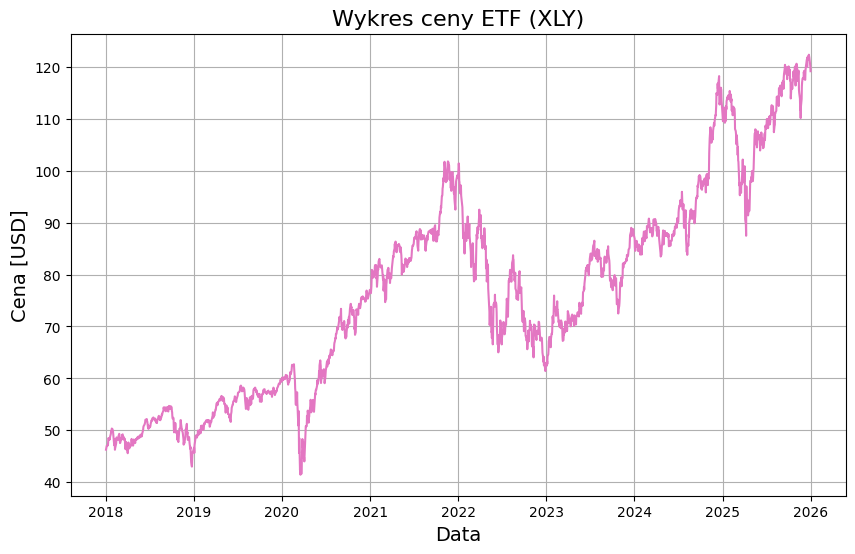

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(Date, Currency, c="C0")
plt.title("Kurs EUR/USD", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Kurs", fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Date, Disney, c="C3")
plt.title("Kurs akcji Walt Disney (DIS)", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Cena [USD]", fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Date, Consumer, c="C6")
plt.title("Wykres ceny ETF (XLY)", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Cena [USD]", fontsize=14)
plt.grid(True)
plt.show()

In [8]:
returns = pd.Series(Disney).pct_change().dropna()
std = returns.std()
print("Odchylenie standardowe stóp zwrotu Disneya:", std)

returns = pd.Series(Consumer).pct_change().dropna()
std = returns.std()
print("Odchylenie standardowe stóp zwrotu Consumera:", std)

returns = pd.Series(Currency).pct_change().dropna()
std = returns.std()
print("Odchylenie standardowe stóp zwrotu Currency:", std)

Odchylenie standardowe stóp zwrotu Disneya: 0.019409906274735413
Odchylenie standardowe stóp zwrotu Consumera: 0.015005152243555512
Odchylenie standardowe stóp zwrotu Currency: 0.004603491914448975


In [9]:
returns_2 = pd.Series(Disney).pct_change().dropna()
var = returns_2.var()
print("Wariancja stóp zwrotu Disneya:", var)

returns_2 = pd.Series(Consumer).pct_change().dropna()
var = returns_2.var()
print("Wariancja stóp zwrotu Consumera:", var)

returns_2 = pd.Series(Currency).pct_change().dropna()
var = returns_2.var()
print("Wariancja stóp zwrotu Currency:", var)

Wariancja stóp zwrotu Disneya: 0.0003767444615940131
Wariancja stóp zwrotu Consumera: 0.00022515459385227902
Wariancja stóp zwrotu Currency: 2.1192137806397088e-05


In [10]:
returns_3 = pd.Series(Disney).pct_change().dropna()
mean = returns_3.mean()
print("Średnia stóp zwrotu Disneya:", mean)

returns_3 = pd.Series(Consumer).pct_change().dropna()
mean = returns_3.mean()
print("Średnia stóp zwrotu Consumera:", mean)

returns_3 = pd.Series(Currency).pct_change().dropna()
mean = returns_3.mean()
print("Średnia stóp zwrotu Currency:", mean)

Średnia stóp zwrotu Disneya: 0.00022180338475028734
Średnia stóp zwrotu Consumera: 0.0005841726903912153
Średnia stóp zwrotu Currency: -4.897893854821556e-07


Wyniki wskazują, że inwestowanie w pojedynczą spółkę wiąże się z większym ryzykiem niż w bardziej stabilne zmienne, takie jak kurs walutowy, natomiast ETF XLY ogranicza to ryzyko w porównaniu do Disneya; wnioski te opierają się na analizie stóp zwrotu liczonych jako zmiany procentowe między kolejnymi dniami.

### **Transformacja danych**

In [11]:
Disney_transformed = Disney.pct_change(fill_method=None).dropna()
Currency_transformed = Currency.pct_change(fill_method=None).dropna()
Consumer_transformed = Consumer.pct_change(fill_method=None).dropna()

Date = Disney_transformed.index

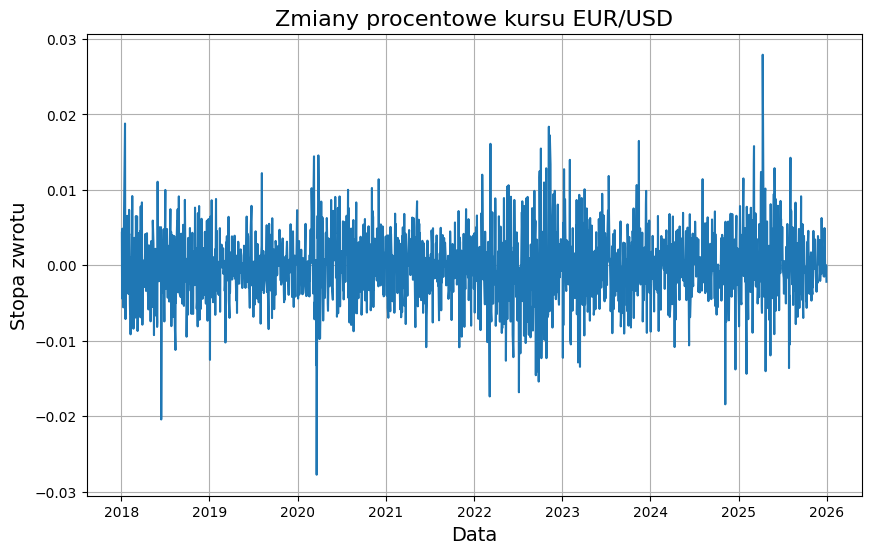

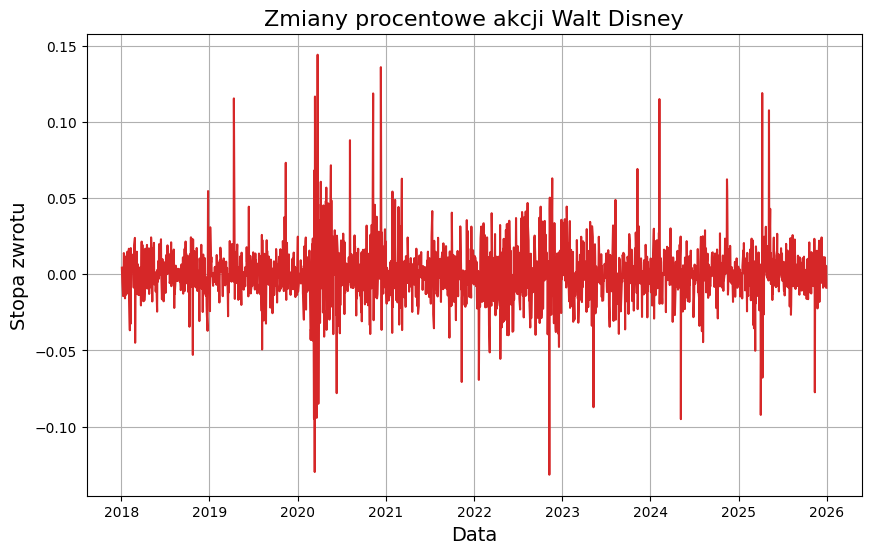

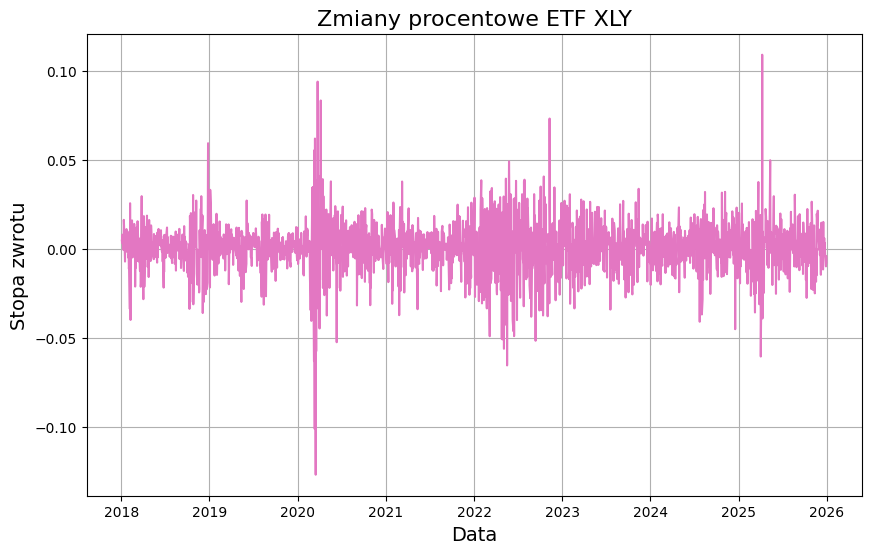

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(Date, Currency_transformed, c="C0")
plt.title("Zmiany procentowe kursu EUR/USD", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Stopa zwrotu", fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Date, Disney_transformed, c="C3")
plt.title("Zmiany procentowe akcji Walt Disney", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Stopa zwrotu", fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(Date, Consumer_transformed, c="C6")
plt.title("Zmiany procentowe ETF XLY", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Stopa zwrotu", fontsize=14)
plt.grid(True)
plt.show()

Największe wahania stóp zwrotu obserwujemy dla Disneya, najmniejsze dla EUR/USD, a XLY znajduje się pomiędzy, co potwierdza wcześniejsze wnioski dotyczące poziomu ryzyka.

In [13]:
Disney_clean_2 = Disney_transformed.dropna()
Currency_clean_2 = Currency_transformed.dropna()
Consumer_clean_2 = Consumer_transformed.dropna()
print(len(Date), len(Disney_clean_2), len(Currency_clean_2), len(Consumer_clean_2))

2008 2008 2008 2008


In [14]:
new_data = {
    "Date": Date,
    "Disney": Disney_clean_2,
    "Consumer": Consumer_clean_2,
    "Currency": Currency_clean_2
}

new_df = pd.DataFrame(new_data)

In [15]:
Date = new_df["Date"]
Disney_clean_2 = new_df["Disney"]
Consumer_clean_2 = new_df["Consumer"]
Currency_clean_2 = new_df["Currency"]

### **ADF test**

In [16]:
def adfuller_test(series, sig=0.05): 
    res = adfuller(series, autolag='AIC')    
    p_value = round(res[1], 3) 
    stats   = round(res[0], 3) 

    if p_value <= sig:
        print(f"Statystyka testowa = {stats}, p-Value = {p_value} => Stationary. ")
    else:
        print(f"Statystyka testowa = {stats}, p-value = {p_value} => Non-stationary.")

In [17]:
adfuller_test(Disney_clean_2)
adfuller_test(Currency_clean_2)
adfuller_test(Consumer_clean_2)

Statystyka testowa = -14.227, p-Value = 0.0 => Stationary. 
Statystyka testowa = -19.748, p-Value = 0.0 => Stationary. 
Statystyka testowa = -14.421, p-Value = 0.0 => Stationary. 


### **Kwantyle**

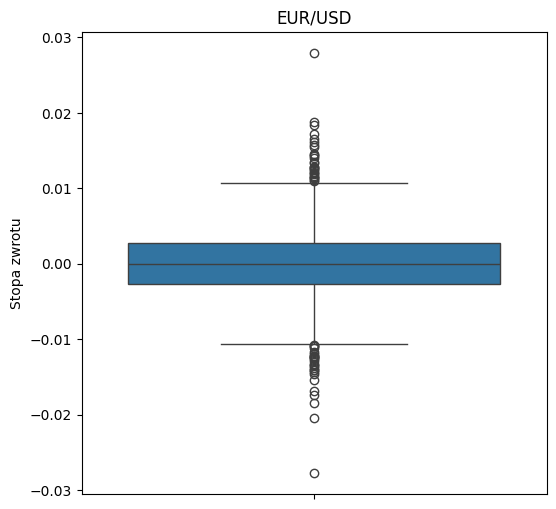

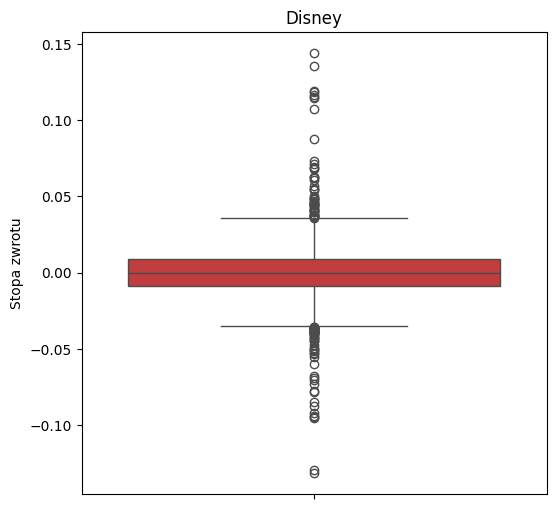

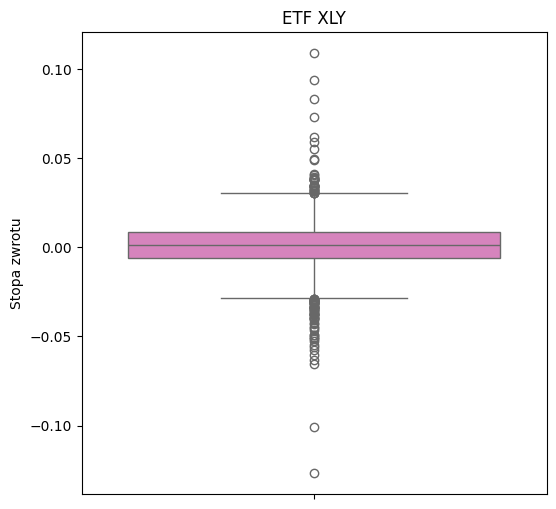

In [18]:
plt.figure(figsize=(6, 6))
sns.boxplot(Currency_transformed, color="C0") 
plt.ylabel("Stopa zwrotu")
plt.title("EUR/USD")
plt.show()

plt.figure(figsize=(6, 6)) 
sns.boxplot(Disney_transformed, color="C3") 
plt.ylabel("Stopa zwrotu")
plt.title("Disney")
plt.show()

plt.figure(figsize=(6, 6)) 
sns.boxplot(Consumer_transformed, color="C6") 
plt.ylabel("Stopa zwrotu")
plt.title("ETF XLY")
plt.show()

In [19]:
Disney_q1 = np.quantile(Disney_clean_2, 0.25, interpolation="midpoint")
Disney_q2 = np.median(Disney_clean_2)
Disney_q3 = np.quantile(Disney_clean_2, 0.75, interpolation="midpoint")

currency_q1 = np.quantile(Currency_clean_2, 0.25, interpolation="midpoint")
currency_q2 = np.median(Currency_clean_2)
currency_q3 = np.quantile(Currency_clean_2, 0.75, interpolation="midpoint")

consumer_q1 = np.quantile(Consumer_clean_2, 0.25, interpolation="midpoint")
consumer_q2 = np.median(Consumer_clean_2)
consumer_q3 = np.quantile(Consumer_clean_2, 0.75, interpolation="midpoint")

data_q = {
    'Kwartyl': ['Q1', 'Q2', 'Q3'],
    'Disney': [Disney_q1, Disney_q2, Disney_q3],
    'EUR/USD': [currency_q1, currency_q2, currency_q3],
    'ETF XLY': [consumer_q1, consumer_q2, consumer_q3]
}

df = pd.DataFrame(data_q)
df


,Kwartyl,Disney,EUR/USD,ETF XLY
0,Q1,-0.008648,-0.002664,-0.006235
1,Q2,0.000000,-0.000040,0.001431
2,Q3,0.009147,0.002741,0.008489


Dla kwantyla 1% widzimy, że w najgorszych przypadkach dzienne straty dla Disneya mogą sięgać około 5%, dla XLY około 4%, a dla EUR/USD tylko około 1%, natomiast kwartyle Q1–Q3 pokazują, że choć rozkłady są skupione wokół zera, zakres wahań jest znacznie większy dla Disneya i XLY niż dla kursu walutowego.

### **Wartości dystrybuanty**

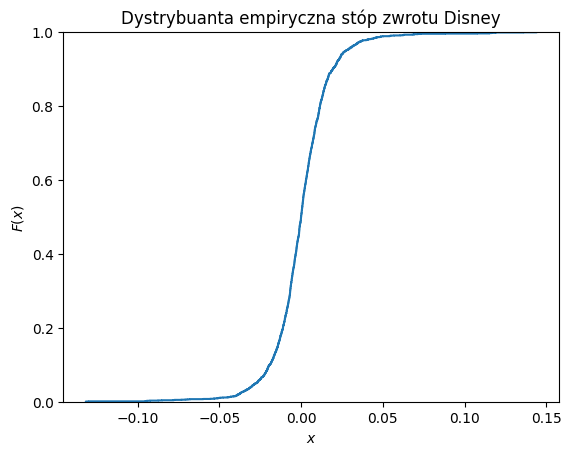

In [20]:
sns.ecdfplot(data = Disney_clean_2)
plt.title("Dystrybuanta empiryczna stóp zwrotu Disney")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.show()

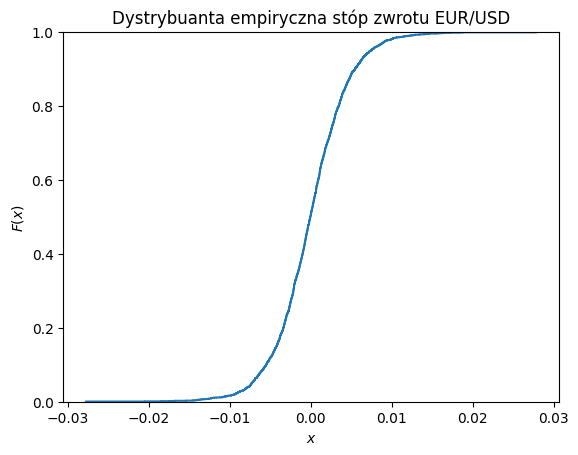

In [21]:
sns.ecdfplot(data=Currency_clean_2)
plt.title("Dystrybuanta empiryczna stóp zwrotu EUR/USD")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.show()

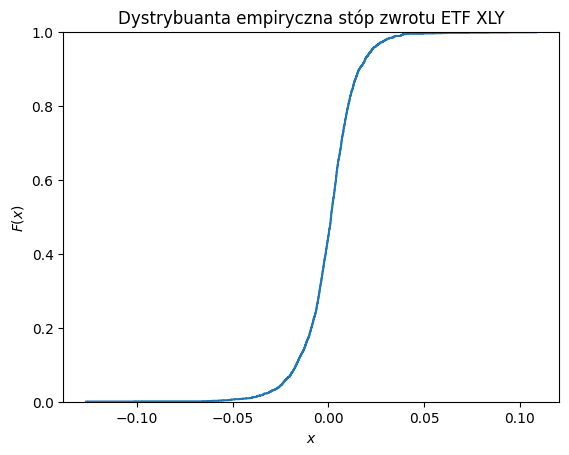

In [22]:
sns.ecdfplot(data=Consumer_clean_2)
plt.title("Dystrybuanta empiryczna stóp zwrotu ETF XLY")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.show()

### Dopasowanie rozkładu

In [23]:
params_Disney = stats.t.fit(Disney_clean_2)
params_Currency = stats.t.fit(Currency_clean_2)
params_Consumer = stats.t.fit(Consumer_clean_2)

t_student_Disney = stats.t(*params_Disney)
t_student_Currency = stats.t(*params_Currency)
t_student_Consumer = stats.t(*params_Consumer)

Disney_sample = t_student_Disney.rvs(size=len(Disney_clean_2))
Currency_sample = t_student_Currency.rvs(size=len(Currency_clean_2))
Consumer_sample = t_student_Consumer.rvs(size=len(Consumer_clean_2))

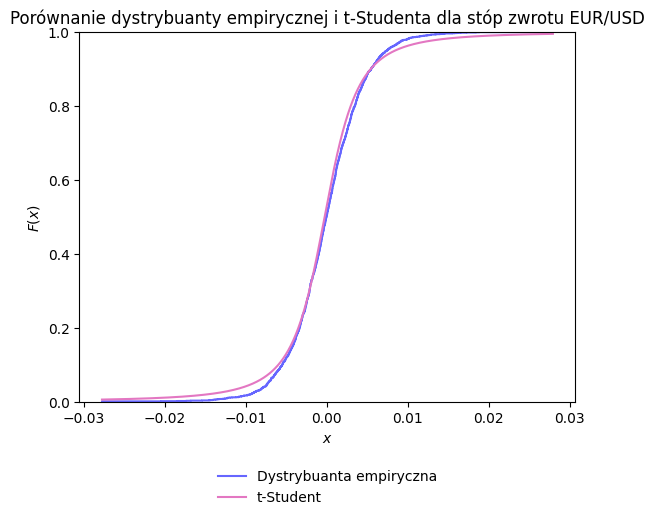

In [24]:
sns.ecdfplot(data = Currency_clean_2, label = "Dystrybuanta empiryczna", color = "b", alpha = 0.6)

t_Currency = np.linspace(np.min(Currency_clean_2), np.max(Currency_clean_2), len(Currency_clean_2))
th_F = t_student_Currency.cdf(t_Currency)
plt.plot(
    t_Currency,
    th_F,
    label=f"t-Student",
    color="C6"
)

plt.title("Porównanie dystrybuanty empirycznej i t-Studenta dla stóp zwrotu EUR/USD")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

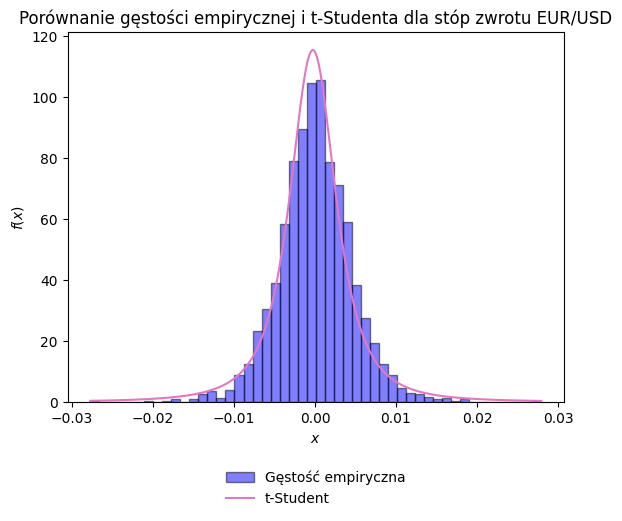

In [25]:
plt.hist(Currency_clean_2, bins = 50, edgecolor='k', density=True, label = "Gęstość empiryczna", color = "b", alpha = 0.5)

f_theo = t_student_Currency.pdf(t_Currency)
plt.plot(
    t_Currency,
    f_theo,
    label=f"t-Student",
    color="C6"
)
plt.title("Porównanie gęstości empirycznej i t-Studenta dla stóp zwrotu EUR/USD")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend(frameon=False,  loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

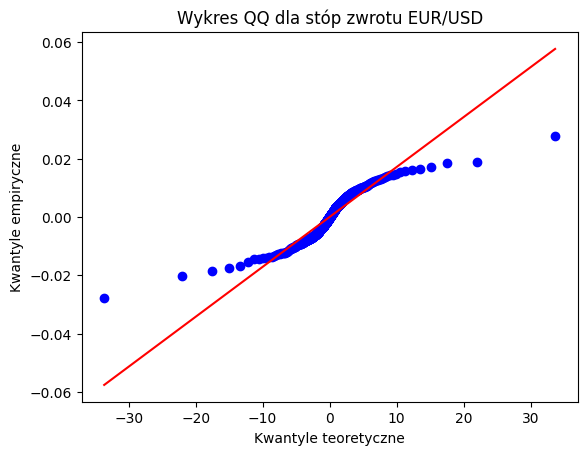

In [26]:
stats.probplot(Currency_clean_2, dist=stats.t, sparams=(params_Currency[0],), plot=plt)

# Dodanie etykiet osi i tytułu
plt.xlabel("Kwantyle teoretyczne")
plt.ylabel("Kwantyle empiryczne")
plt.title("Wykres QQ dla stóp zwrotu EUR/USD")
plt.show()


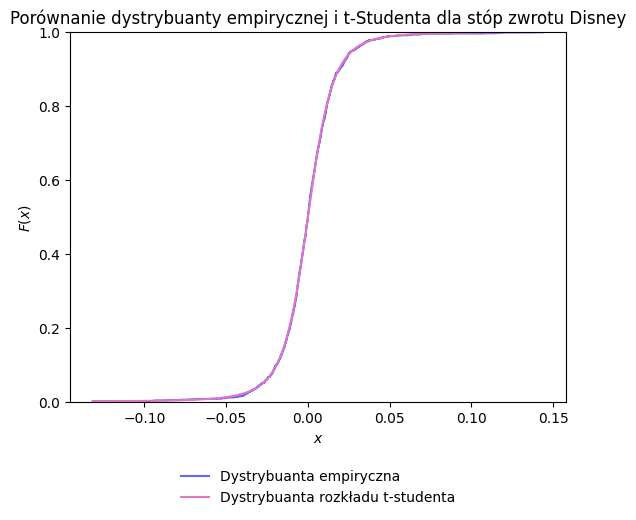

In [27]:
sns.ecdfplot(data = Disney_clean_2, label = "Dystrybuanta empiryczna", color = "b", alpha = 0.6)

t_Disney = np.linspace(np.min(Disney_clean_2), np.max(Disney_clean_2), len(Disney_clean_2))
th_F = t_student_Disney.cdf(t_Disney)
plt.plot(t_Disney, th_F, label = f"Dystrybuanta rozkładu t-studenta", color = "C6")

plt.title("Porównanie dystrybuanty empirycznej i t-Studenta dla stóp zwrotu Disney")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend(frameon=False,  loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

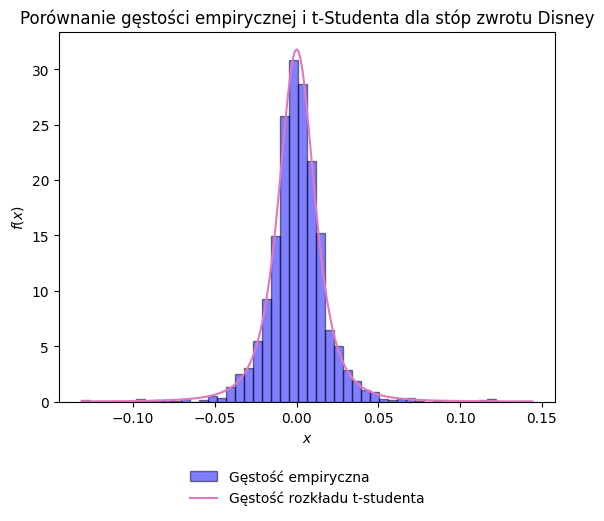

In [28]:
plt.hist(Disney_clean_2, bins = 50, edgecolor='k', density=True, label = "Gęstość empiryczna", color = "b", alpha = 0.5)

f_theo = t_student_Disney.pdf(t_Disney)
plt.plot(t_Disney, f_theo, label = f"Gęstość rozkładu t-studenta", color = "C6")
plt.title("Porównanie gęstości empirycznej i t-Studenta dla stóp zwrotu Disney")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend(frameon=False,  loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

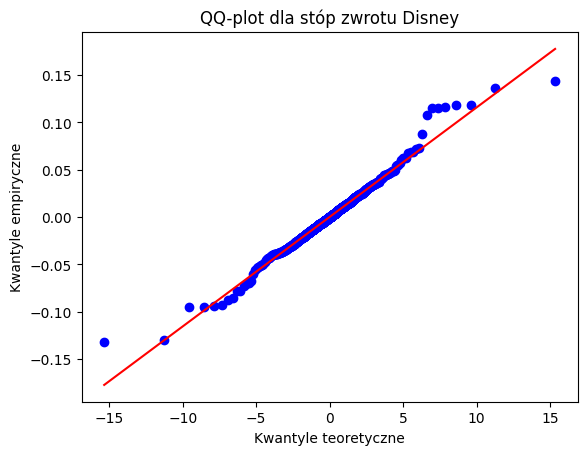

In [29]:
stats.probplot(Disney_clean_2, dist=stats.t, sparams=(params_Disney[0],), plot=plt)
plt.xlabel("Kwantyle teoretyczne")
plt.ylabel("Kwantyle empiryczne")
plt.title("QQ-plot dla stóp zwrotu Disney")
plt.show()


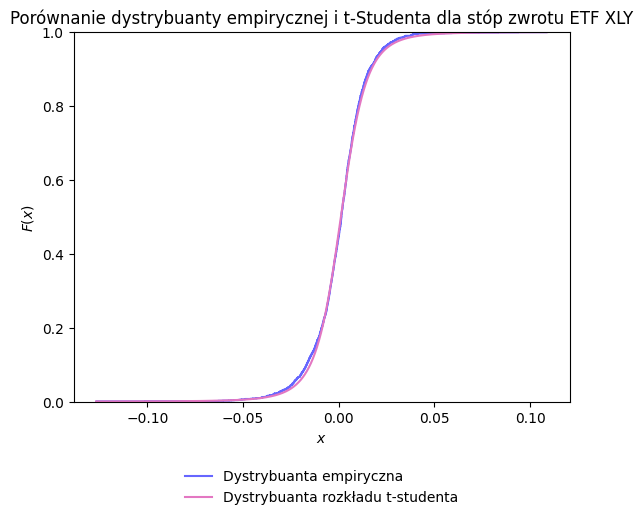

In [30]:
sns.ecdfplot(data = Consumer_clean_2, label = "Dystrybuanta empiryczna", color = "b", alpha = 0.6)

t_Consumer = np.linspace(np.min(Consumer_clean_2), np.max(Consumer_clean_2), len(Consumer_clean_2))
th_F = t_student_Consumer.cdf(t_Consumer)
plt.plot(t_Consumer, th_F, label = f"Dystrybuanta rozkładu t-studenta", color = "C6")

plt.title("Porównanie dystrybuanty empirycznej i t-Studenta dla stóp zwrotu ETF XLY")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend(frameon=False,  loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

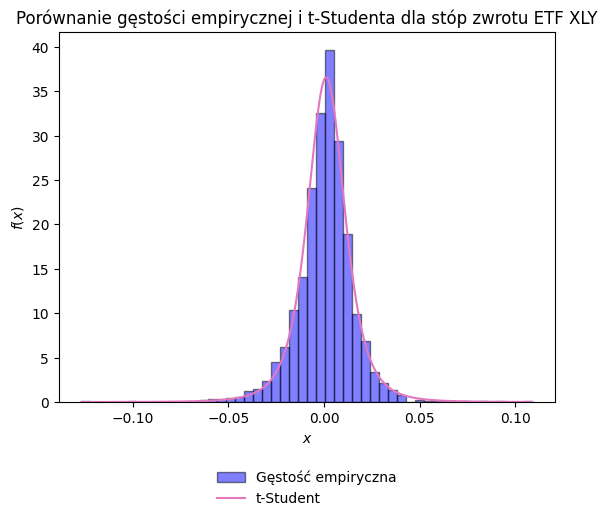

In [31]:
plt.hist(Consumer_clean_2, bins=50, edgecolor='k', density=True,
         label="Gęstość empiryczna", color="b", alpha=0.5)

f_theo = t_student_Consumer.pdf(t_Consumer)
plt.plot(
    t_Consumer,
    f_theo,
    label=f"t-Student",
    color="C6"
)

plt.title("Porównanie gęstości empirycznej i t-Studenta dla stóp zwrotu ETF XLY")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.show()

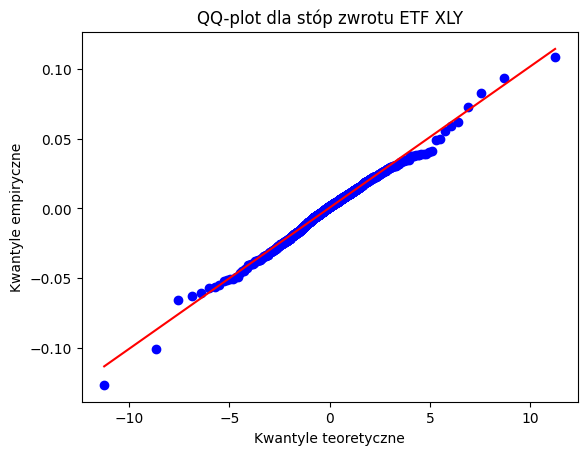

In [32]:
stats.probplot(Consumer_clean_2, dist=stats.t, sparams=(params_Consumer[0],), plot=plt)
plt.xlabel("Kwantyle teoretyczne")
plt.ylabel("Kwantyle empiryczne")
plt.title("QQ-plot dla stóp zwrotu ETF XLY")
plt.show()

Rozkład t-Studenta dobrze opisuje stopy zwrotu Disneya i XLY, co wskazuje na obecność grubych ogonów i większe prawdopodobieństwo skrajnych zmian. W przypadku EUR/USD widoczne jest gorsze dopasowanie, co sugeruje, że rozkład t-Studenta nie oddaje w pełni charakteru danych.

### **Miary ryzyka wyznaczone podejściem nieparametrycznym**

In [33]:
def semi_standard_deviation(data):
    mean = np.mean(data)  # Średnia
    deviations = data - mean  # Różnice od średniej
    negative_deviations = deviations[deviations < 0]  
    semi_std = np.mean(np.abs(negative_deviations))  
    return semi_std

In [34]:
data_Disney = {
    'Nazwa_miary_zmiennosci': [
        'Odchylenie_standardowe',
        'Odchylenie_przecietne',
        'Odchylenie_cwiartkowe',
        'Semiodchylenie_standardowe',
        'Semiodchylenie_przecietne'
    ],

    'Disney (t-Student)': [
        np.std(Disney_sample),
        np.mean(np.abs(Disney_sample - np.mean(Disney_sample))),
        (1/2) * (
            np.quantile(Disney_sample, 0.75, interpolation="midpoint")
            - np.quantile(Disney_sample, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Disney_sample),
        np.mean(np.abs(Disney_sample[Disney_sample < np.mean(Disney_sample)] - np.mean(Disney_sample)))
    ],

    'Disney (dane)': [
        np.std(Disney_clean_2),
        np.mean(np.abs(Disney_clean_2 - np.mean(Disney_clean_2))),
        (1/2) * (
            np.quantile(Disney_clean_2, 0.75, interpolation="midpoint")
            - np.quantile(Disney_clean_2, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Disney_clean_2),
        np.mean(np.abs(Disney_clean_2[Disney_clean_2 < np.mean(Disney_clean_2)] - np.mean(Disney_clean_2)))
    ]
}

df = pd.DataFrame(data_Disney)
df

,Nazwa_miary_zmiennosci,Disney (t-Student),Disney (dane)
0,Odchylenie_standardowe,0.017603,0.019405
1,Odchylenie_przecietne,0.012088,0.012820
2,Odchylenie_cwiartkowe,0.008428,0.008897
3,Semiodchylenie_standardowe,0.012334,0.012606
4,Semiodchylenie_przecietne,0.012334,0.012606


In [35]:
data = {
    'Nazwa_miary_zmiennosci': ['Odchylenie_standardowe', 'Odchylenie_przecietne', 'Odchylenie_cwiartkowe', 'Semiodchylenie_standardowe', 'Semiodchylenie_przecietne'],
    'EUR/USD (t-Student)': [
        np.std(Currency_sample),
        np.mean(np.abs(Currency_sample - np.mean(Currency_sample))),
        (1/2) * (np.quantile(Currency_sample, 0.75, interpolation="midpoint") - np.quantile(Currency_sample, 0.25, interpolation="midpoint")),
        semi_standard_deviation(Currency_sample),      
        np.mean(np.abs(Currency_sample[Currency_sample < np.mean(Currency_sample)] - np.mean(Currency_sample)))
    ],
    'EUR/USD (dane)': [
        np.std(Currency_clean_2),
        np.mean(np.abs(Currency_clean_2 - np.mean(Currency_clean_2))),
        (1/2) * (np.quantile(Currency_clean_2, 0.75, interpolation="midpoint") - np.quantile(Currency_clean_2, 0.25, interpolation="midpoint")),
        semi_standard_deviation(Currency_clean_2),   
        np.mean(np.abs(Currency_clean_2[Currency_clean_2 < np.mean(Currency_clean_2)] - np.mean(Currency_clean_2)))
    ]
}


df = pd.DataFrame(data)
df

,Nazwa_miary_zmiennosci,EUR/USD (t-Student),EUR/USD (dane)
0,Odchylenie_standardowe,0.010066,0.004602
1,Odchylenie_przecietne,0.004315,0.003455
2,Odchylenie_cwiartkowe,0.002412,0.002703
3,Semiodchylenie_standardowe,0.004394,0.003441
4,Semiodchylenie_przecietne,0.004394,0.003441


In [36]:
data_Consumer = {
    'Nazwa_miary_zmiennosci': [
        'Odchylenie_standardowe',
        'Odchylenie_przecietne',
        'Odchylenie_cwiartkowe',
        'Semiodchylenie_standardowe',
        'Semiodchylenie_przecietne'
    ],

    'ETF XLY (t-Student)': [
        np.std(Consumer_sample),
        np.mean(np.abs(Consumer_sample - np.mean(Consumer_sample))),
        (1/2) * (
            np.quantile(Consumer_sample, 0.75, interpolation="midpoint")
            - np.quantile(Consumer_sample, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Consumer_sample),
        np.mean(np.abs(Consumer_sample[Consumer_sample < np.mean(Consumer_sample)] - np.mean(Consumer_sample)))
    ],

    'ETF XLY (dane)': [
        np.std(Consumer_clean_2),
        np.mean(np.abs(Consumer_clean_2 - np.mean(Consumer_clean_2))),
        (1/2) * (
            np.quantile(Consumer_clean_2, 0.75, interpolation="midpoint")
            - np.quantile(Consumer_clean_2, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Consumer_clean_2),
        np.mean(np.abs(Consumer_clean_2[Consumer_clean_2 < np.mean(Consumer_clean_2)] - np.mean(Consumer_clean_2)))
    ]
}

df = pd.DataFrame(data_Consumer)
df

,Nazwa_miary_zmiennosci,ETF XLY (t-Student),ETF XLY (dane)
0,Odchylenie_standardowe,0.014891,0.015001
1,Odchylenie_przecietne,0.010389,0.010510
2,Odchylenie_cwiartkowe,0.007482,0.007362
3,Semiodchylenie_standardowe,0.010389,0.011238
4,Semiodchylenie_przecietne,0.010389,0.011238


Odchylenie przeciętne dla Disneya wynosi około 0.0128, podczas gdy dla EUR/USD jedynie 0.0035, co oznacza, że przeciętne odchylenia od średniej są ponad trzykrotnie większe dla akcji. Podobna relacja widoczna jest w semiodchyleniu, co pokazuje, że także przeciętne spadki są znacznie większe dla Disneya. Oznacza to, że nie tylko skrajne, ale również typowe wahania są istotnie większe dla rynku akcji niż dla kursu walutowego.

In [37]:
all_data_filtered = all_data.copy() 
all_data_filtered["disney"] = Disney_transformed
all_data_filtered["currency"] = Currency_transformed

all_data_filtered.to_csv("disney_currency.csv", index=False)
all_data_filtered

Ticker,disney,fx,consumer,currency
Date,,,,
2018-01-02,NaN,1.201158,46.275242,NaN
2018-01-03,0.004293,1.206345,46.487690,0.004319
2018-01-04,-0.000445,1.201043,46.640125,-0.004396
2018-01-05,-0.005435,1.206884,47.009613,0.004864
2018-01-08,-0.014334,1.203746,47.065037,-0.002600
...,...,...,...,...
2025-12-24,0.011129,1.179551,122.344231,0.002513
2025-12-26,-0.008036,1.178536,121.805321,-0.000860
2025-12-29,0.005548,1.177274,120.607719,-0.001071


# 2. Przypadek wielowymiarowy

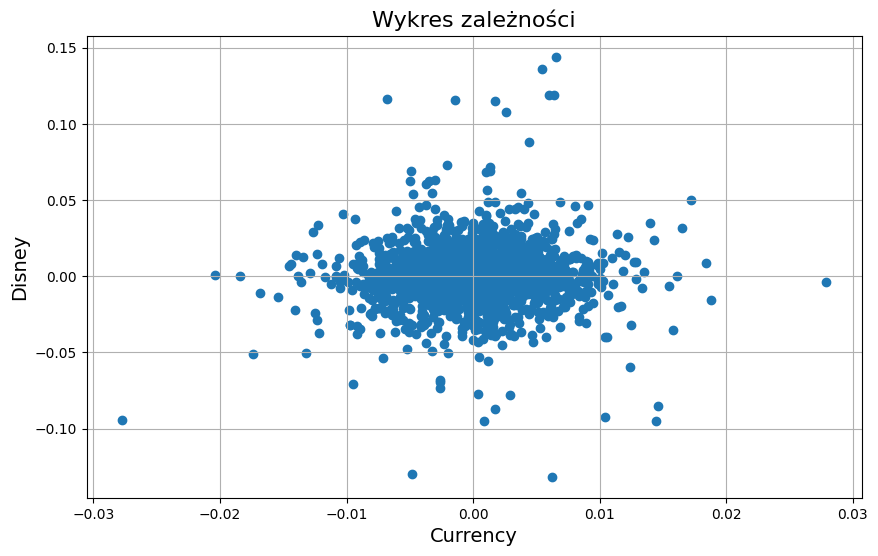

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(Currency_clean_2, Disney_clean_2)
plt.title("Wykres zależności", fontsize=16)
plt.xlabel("Currency", fontsize=14)
plt.ylabel("Disney", fontsize=14)
plt.grid(True)
plt.show()

In [39]:
a = 0.35
b = 0.25
c = 0.40

Wallet = np.multiply(a, Disney_clean_2) + np.multiply(b, Currency_clean_2) + np.multiply(c, Consumer_clean_2)
# Date = Date[1:]

Zastosowana struktura wag (40% ETF, 35% Disney, 25% waluta) została wybrana poprzez kierowanie się celem zbilansowania akcji, aby uzyskać jak największą stopę zwrotu. Fundusz konsumencki stabilizuje portfel, a akcja Disneya ze względu na wyższe ryzyko, ale i większy zysk jest w stanie podwyższyć jego rentowność. Udział waluty pełni rolę bufora, który amortyzuje krachy giełdowe, zapewniając korzystniejszy stosunek zysku do ryzyka.

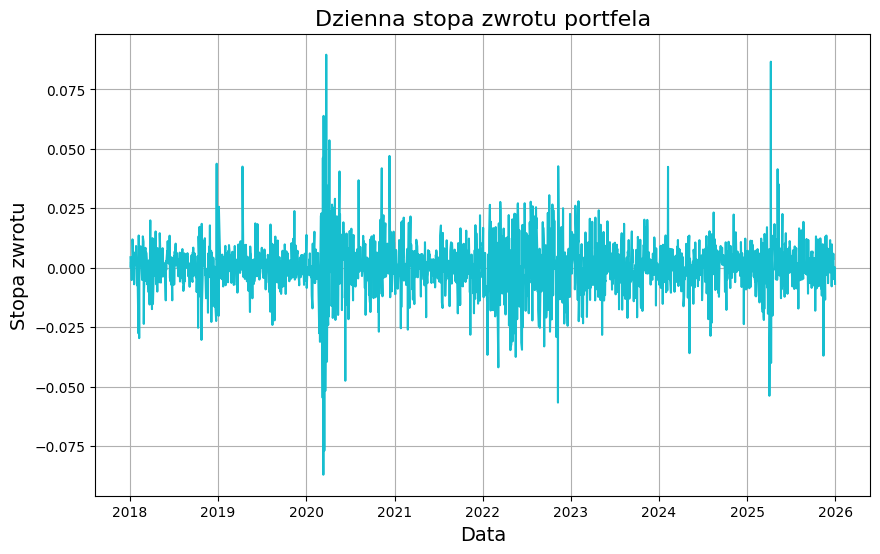

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(Date, Wallet, c="C9")
plt.title("Dzienna stopa zwrotu portfela", fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Stopa zwrotu", fontsize=14)
plt.grid(True)
plt.show()

Jak widać na wykresie, mimo obecności ryzykownych akcji, codzienne wahania portfela oscylują wokół zera. Największe odchylenia są widoczne jedynie w momentach globalnych kryzysów, takich jak np. pandemia koronawirusa w 2020 roku, co świadczy o odporności naszych inwestycji na mniejsze, codzienne spadki rynkowe.

### **Miara/y zmienności dla portfela**

In [41]:
data = {
    'Nazwa_miary_zmiennosci': [
        'Odchylenie_standardowe',
        'Odchylenie_przecietne',
        'Odchylenie_cwiartkowe',
        'Semiodchylenie_standardowe',
        'Semiodchylenie_przecietne'
    ],

    'Currency': [
        np.std(Currency_clean_2),
        np.mean(np.abs(Currency_clean_2 - np.mean(Currency_clean_2))),
        (1/2) * (
            np.quantile(Currency_clean_2, 0.75, interpolation="midpoint")
            - np.quantile(Currency_clean_2, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Currency_clean_2),
        np.mean(np.abs(Currency_clean_2[Currency_clean_2 < np.mean(Currency_clean_2)] - np.mean(Currency_clean_2)))
    ],

    'Disney': [
        np.std(Disney_clean_2),
        np.mean(np.abs(Disney_clean_2 - np.mean(Disney_clean_2))),
        (1/2) * (
            np.quantile(Disney_clean_2, 0.75, interpolation="midpoint")
            - np.quantile(Disney_clean_2, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Disney_clean_2),
        np.mean(np.abs(Disney_clean_2[Disney_clean_2 < np.mean(Disney_clean_2)] - np.mean(Disney_clean_2)))
    ],

    'Consumer': [
        np.std(Consumer_clean_2),
        np.mean(np.abs(Consumer_clean_2 - np.mean(Consumer_clean_2))),
        (1/2) * (
            np.quantile(Consumer_clean_2, 0.75, interpolation="midpoint")
            - np.quantile(Consumer_clean_2, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Consumer_clean_2),
        np.mean(np.abs(Consumer_clean_2[Consumer_clean_2 < np.mean(Consumer_clean_2)] - np.mean(Consumer_clean_2)))
    ],

    'Wallet': [
        np.std(Wallet),
        np.mean(np.abs(Wallet - np.mean(Wallet))),
        (1/2) * (
            np.quantile(Wallet, 0.75, interpolation="midpoint")
            - np.quantile(Wallet, 0.25, interpolation="midpoint")
        ),
        semi_standard_deviation(Wallet),
        np.mean(np.abs(Wallet[Wallet < np.mean(Wallet)] - np.mean(Wallet)))
    ]
}

df = pd.DataFrame(data)
df

,Nazwa_miary_zmiennosci,Currency,Disney,Consumer,Wallet
0,Odchylenie_standardowe,0.004602,0.019405,0.015001,0.011638
1,Odchylenie_przecietne,0.003455,0.012820,0.010510,0.008005
2,Odchylenie_cwiartkowe,0.002703,0.008897,0.007362,0.005748
3,Semiodchylenie_standardowe,0.003441,0.012606,0.011238,0.008328
4,Semiodchylenie_przecietne,0.003441,0.012606,0.011238,0.008328


Z tabeli wynika, że konstrukcja portfela spełniła główne zadanie: znacznie obniżyła ryzyko inwestycyjne. Odchylenie standardowe portfela jest niemal o połowę niższe niż w przypadku najbardziej ryzykownej akcji - Disneya. Jednocześnie niska wartość odchylenia ćwiartkowego udowadnia, że w przeciętny dzień giełdowy portfel jest wysoce przewidywalny.

### **Kwantyle**

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


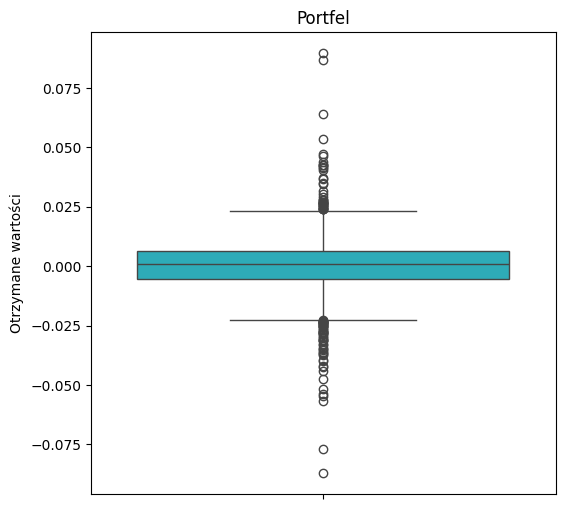

In [42]:
plt.figure(figsize=(6, 6)) 
sns.boxplot(list(Wallet), color="C9") 
plt.ylabel("Otrzymane wartości")
plt.title("Portfel")
plt.legend(frameon=False, fontsize = 11)
plt.show()

In [43]:
wallet_q1 = np.quantile(Wallet, 0.25, method="midpoint")
wallet_q2 = np.median(Wallet)
wallet_q3 = np.quantile(Wallet, 0.75, method="midpoint")

wallet_var_5 = np.quantile(Wallet, 0.05, method="midpoint")
wallet_var_1 = np.quantile(Wallet, 0.01, method="midpoint")

data_q = {
    'Miara': ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'VaR 5%', 'VaR 1%'],
    'Wallet': [wallet_q1, wallet_q2, wallet_q3, wallet_var_5, wallet_var_1],
}

df_quantiles = pd.DataFrame(data_q)
df_quantiles


,Miara,Wallet
0,Q1 (25%),-0.005294
1,Mediana (50%),0.000769
2,Q3 (75%),0.006203
3,VaR 5%,-0.018066
4,VaR 1%,-0.032052


Wynik dla kwantyla 1% udowadnia, że w najgorszym przypadku nasza maksymalna dzienna strata to zaledwie 3,2%, co stanowi bezpieczny bufor. Co więcej, dodatnia wartość mediany potwierdza, że pomimo zmian na giełdzie, portfel w więcej niż połowie dni inwestycji wyjdzie na plus.

In [44]:
params_Wallet = stats.t.fit(Wallet)
t_student_Wallet = stats.t(*params_Wallet)
Wallet_sample = t_student_Wallet.rvs(size=len(Wallet))

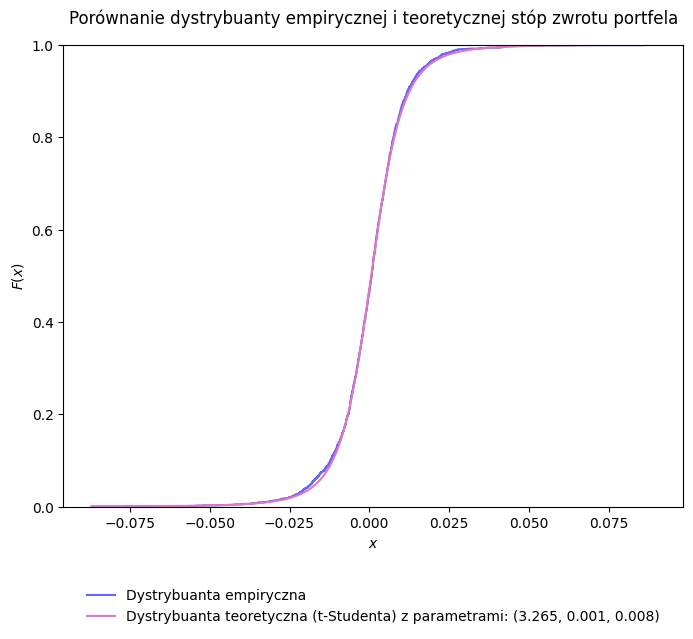

In [45]:
plt.figure(figsize=(8, 6))
sns.ecdfplot(data = Wallet, label = "Dystrybuanta empiryczna", color = "b", alpha = 0.6)

t_Wallet = np.linspace(np.min(Wallet), np.max(Wallet), len(Wallet))
th_F = t_student_Wallet.cdf(t_Wallet)
plt.plot(
    t_Wallet, 
    th_F, 
    label=f"Dystrybuanta teoretyczna (t-Studenta) z parametrami: ({params_Wallet[0]:.3f}, {params_Wallet[1]:.3f}, {params_Wallet[2]:.3f})",  
    color="C6"
)
plt.title("Porównanie dystrybuanty empirycznej i teoretycznej stóp zwrotu portfela", pad=15)
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15))

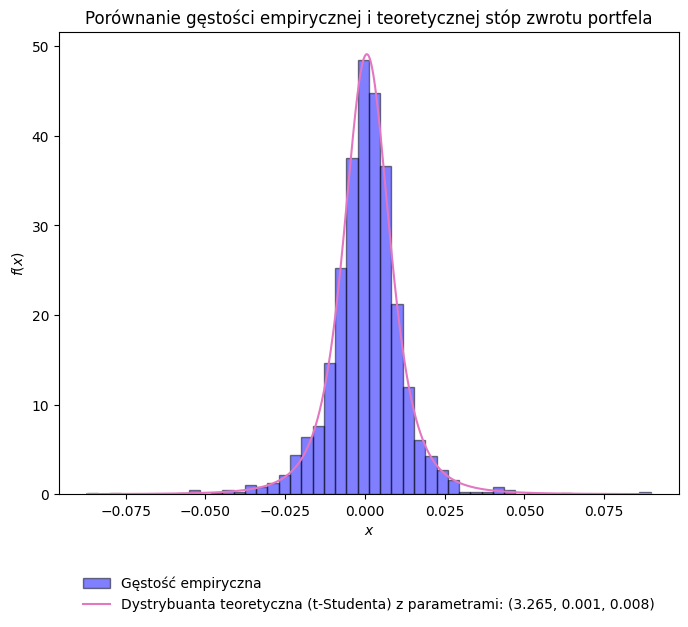

In [46]:
plt.figure(figsize=(8, 6))
plt.hist(Wallet, bins = 50, edgecolor='k', density=True, label = "Gęstość empiryczna", color = "b", alpha = 0.5)

f_theo = t_student_Wallet.pdf(t_Wallet)
plt.plot(
    t_Wallet, 
    f_theo, 
    label=f"Dystrybuanta teoretyczna (t-Studenta) z parametrami: ({params_Wallet[0]:.3f}, {params_Wallet[1]:.3f}, {params_Wallet[2]:.3f})",  
    color="C6"
)
plt.title("Porównanie gęstości empirycznej i teoretycznej stóp zwrotu portfela")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend(frameon=False,  loc='upper center', bbox_to_anchor=(0.5, -0.15))

Text(0.5, 1.0, 'Wykres kwantylowy dla stóp zwrotu portfela')

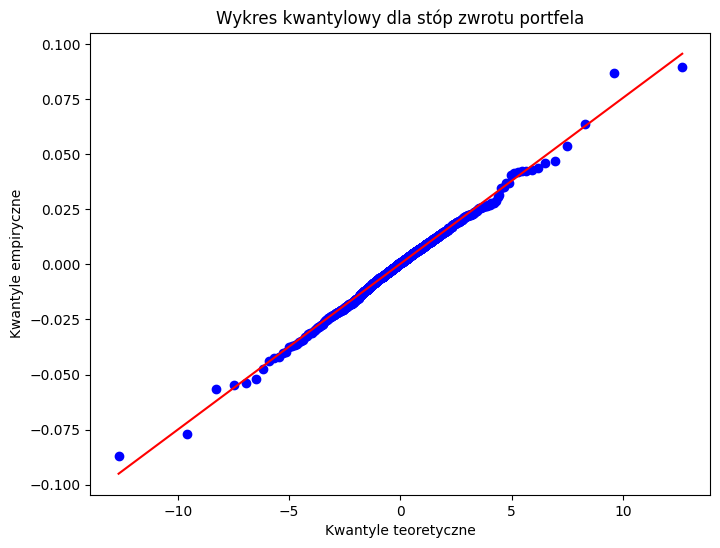

In [47]:
plt.figure(figsize=(8, 6))
stats.probplot(Wallet, dist=stats.t, sparams=(params_Wallet[0],), plot=plt)
plt.xlabel("Kwantyle teoretyczne")
plt.ylabel("Kwantyle empiryczne")
plt.title("Wykres kwantylowy dla stóp zwrotu portfela")

Zastosowanie rozkładu t-Studenta okazało się dobrym wyborem, co widać po perfekcyjnym nałożeniu się modelu matematycznego na nasze dane empiryczne. Wykres kwantylowy potwierdza, że punkty układają się wzdłuż linii, dobrze odzwierciedlając ryzyko w 95% przypadków. Odchylenia na samych skrajach to naturalny efekt rynkowych krachów na rynku.

### **Dystrybuanta wielowymiarowa**

In [48]:
def multi_ecdf(R1, R2):
    n1 = len(R1)
    n2 = len(R2)

    R1 = np.sort(R1)
    R2 = np.sort(R2)
    
    a = np.min(R1)
    b = np.max(R1)
    X = np.linspace(a, b, n1)
    
    c = np.min(R2)
    d = np.max(R2)
    Y = np.linspace(c, d, n2)
    
    Z1 = X.reshape(-1, 1) <= R1.reshape(1, -1)
    Z1 = np.sum(Z1, axis=1)[::-1].reshape(1, -1)
    Z2 = Y.reshape(-1, 1) <= R2.reshape(1, -1)
    Z2 = np.sum(Z2, axis=1)[::-1].reshape(-1, 1)

    Z = np.dot(Z2, Z1) / n1 / n2
    return X, Y, Z

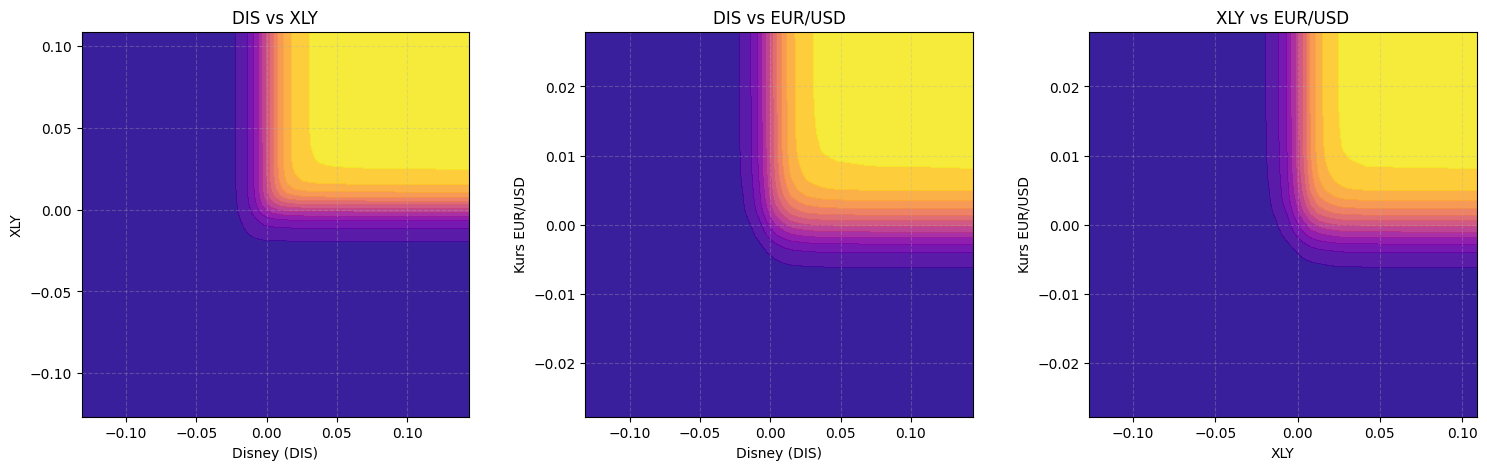

In [49]:
def plot_2d_ecdf(x_data, y_data, xlabel, ylabel, ax):
    x_grid = np.linspace(np.min(x_data), np.max(x_data), 50)
    y_grid = np.linspace(np.min(y_data), np.max(y_data), 50)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = np.mean((x_data <= X[i, j]) & (y_data <= Y[i, j]))
            
    contour = ax.contourf(X, Y, Z, cmap='plasma', levels=15, alpha=0.9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    return contour

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = plot_2d_ecdf(Disney_clean_2, Consumer_clean_2, 'Disney (DIS)', 'XLY', axes[0])
axes[0].set_title('DIS vs XLY')

c2 = plot_2d_ecdf(Disney_clean_2, Currency_clean_2, 'Disney (DIS)', 'Kurs EUR/USD', axes[1])
axes[1].set_title('DIS vs EUR/USD')

c3 = plot_2d_ecdf(Consumer_clean_2, Currency_clean_2, 'XLY', 'Kurs EUR/USD', axes[2])
axes[2].set_title('XLY vs EUR/USD')

plt.subplots_adjust(wspace=0.3)
plt.show()

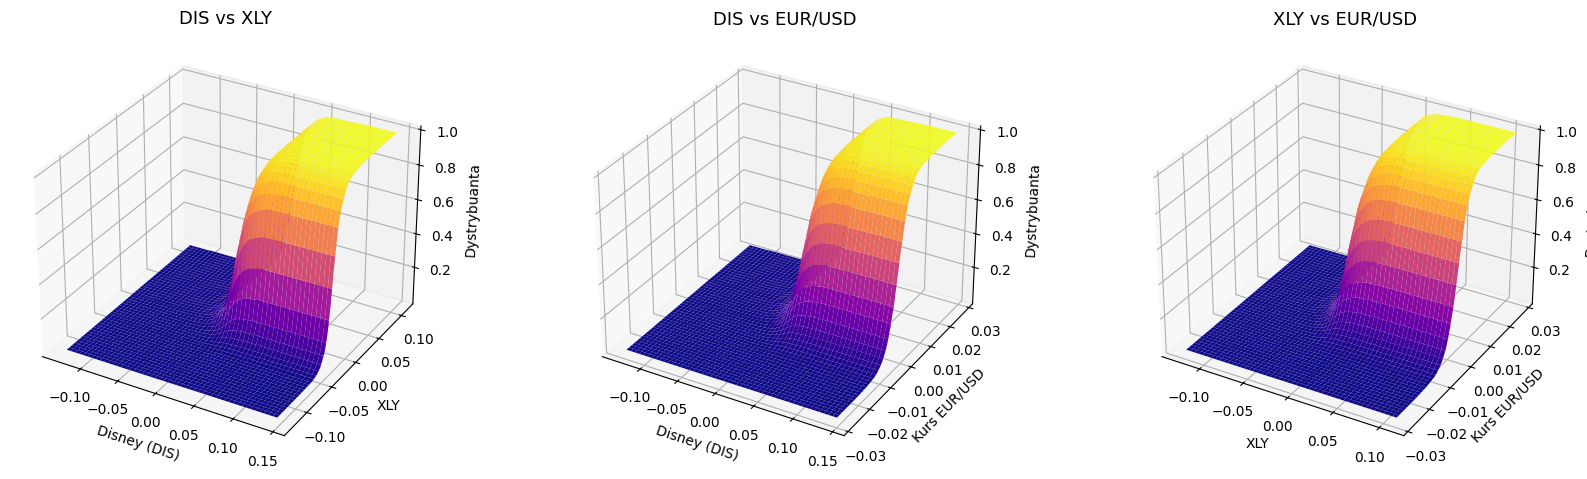

In [50]:
fig = plt.figure(figsize=(20, 7))

X1, Y1, Z1 = multi_ecdf(Disney_clean_2, Consumer_clean_2)
X1_mesh, Y1_mesh = np.meshgrid(X1, Y1)

ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X1_mesh, Y1_mesh, Z1, cmap='plasma')
ax1.set_xlabel('Disney (DIS)')
ax1.set_ylabel('XLY')
ax1.set_zlabel('Dystrybuanta')
ax1.set_title('DIS vs XLY', fontsize=13)

X2, Y2, Z2 = multi_ecdf(Disney_clean_2, Currency_clean_2)
X2_mesh, Y2_mesh = np.meshgrid(X2, Y2)

ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X2_mesh, Y2_mesh, Z2, cmap='plasma')
ax2.set_xlabel('Disney (DIS)')
ax2.set_ylabel('Kurs EUR/USD')
ax2.set_zlabel('Dystrybuanta')
ax2.set_title('DIS vs EUR/USD', fontsize=13)

X3, Y3, Z3 = multi_ecdf(Consumer_clean_2, Currency_clean_2)
X3_mesh, Y3_mesh = np.meshgrid(X3, Y3)

ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X3_mesh, Y3_mesh, Z3, cmap='plasma')
ax3.set_xlabel('XLY')
ax3.set_ylabel('Kurs EUR/USD')
ax3.set_zlabel('Dystrybuanta')
ax3.set_title('XLY vs EUR/USD', fontsize=13)

plt.subplots_adjust(wspace=0.3)

plt.show()

Wizualizacje dwuwymiarowe uwydatniają rolę waluty EUR/USD, która działa jako amortyzator - nawet gdy akcje gwałtownie tracą, ona powstrzymuje portfel przed całkowitym załamaniem. Wykresy 3D dla par z walutą są bardziej strome, co matematycznie odcina strefę jednoczesnych, ekstremalnych strat. Można zwrócić też uwagę na dużą zależność panującą między Disney'em a XLY - wartość obu tych akcji jest powiązana ściśle z rynkiem konsumenckim USA.

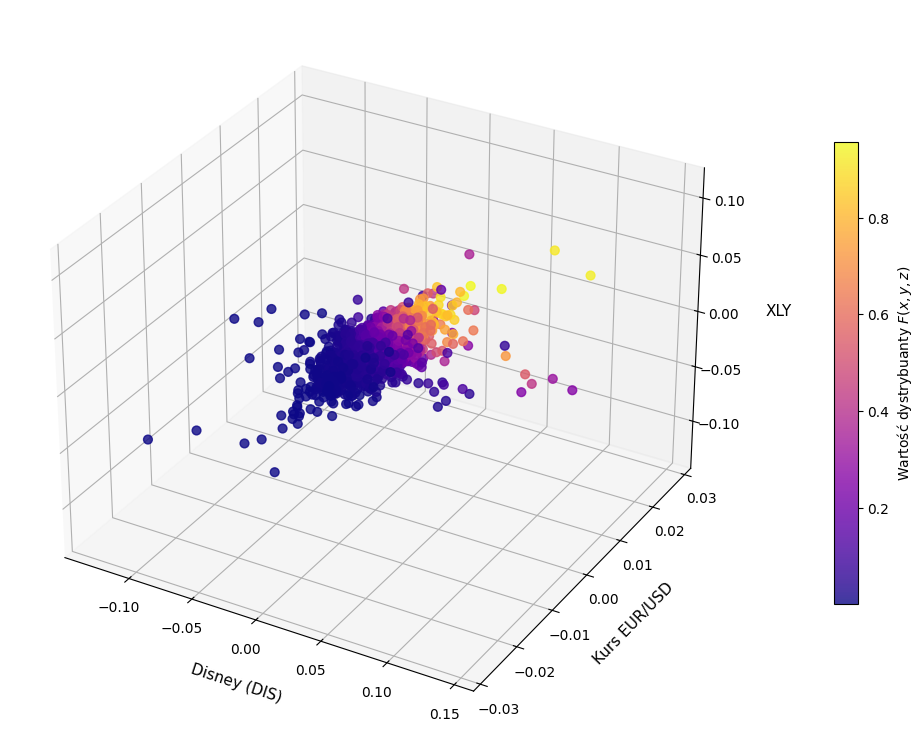

In [51]:

data_matrix = np.column_stack((Disney_clean_2, Currency_clean_2, Consumer_clean_2))
n_obs = len(data_matrix)

F_values = np.zeros(n_obs)
for i in range(n_obs):
    x_ref, y_ref, z_ref = data_matrix[i]
    
    warunek = (data_matrix[:, 0] <= x_ref) & \
              (data_matrix[:, 1] <= y_ref) & \
              (data_matrix[:, 2] <= z_ref)
              
    F_values[i] = np.sum(warunek) / n_obs

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Tworzymy scatter plot
scatter = ax.scatter(data_matrix[:, 0],
                     data_matrix[:, 1],
                     data_matrix[:, 2],
                     c=F_values,
                     cmap='plasma', 
                     alpha=0.8, 
                     s=40)

ax.set_xlabel('Disney (DIS)', fontsize=11, labelpad=10)
ax.set_ylabel('Kurs EUR/USD', fontsize=11, labelpad=10)
ax.set_zlabel('XLY', fontsize=11, labelpad=15)


cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Wartość dystrybuanty $F(x,y,z)$', fontsize=10)

plt.tight_layout()

plt.show()

Silne zbicie punktów w centrum wykresu oznacza, że wahania Disneya, ETF'u i waluty wzajemnie tłumią swoje ekstrema. Udowadnia to, że prawdopodobieństwo wystąpienia dnia, w którym wszystkie trzy elementy portfela zawiodą nas dokładnie w tym samym momencie, jest niemal równe zeru.

In [52]:
df_all = pd.DataFrame({
    'Disney (DIS)': Disney_clean_2,
    'Kurs EUR/USD': Currency_clean_2,
    'ETF XLY': Consumer_clean_2,
    'PORTFEL': Wallet
})

srednie = df_all.mean()
wariancje = df_all.var()
odchylenia = df_all.std()

tabela_wynikow = pd.DataFrame({
    'Średnia': srednie,
    'Wariancja': wariancje,
    'Odchylenie Std': odchylenia
})
print("Statystyki opisowe stóp zwrotu:")
print(tabela_wynikow.round(6))

Statystyki opisowe stóp zwrotu:
               Średnia  Wariancja  Odchylenie Std
Disney (DIS)  0.000222   0.000377        0.019410
Kurs EUR/USD -0.000000   0.000021        0.004603
ETF XLY       0.000584   0.000225        0.015005
PORTFEL       0.000311   0.000136        0.011641


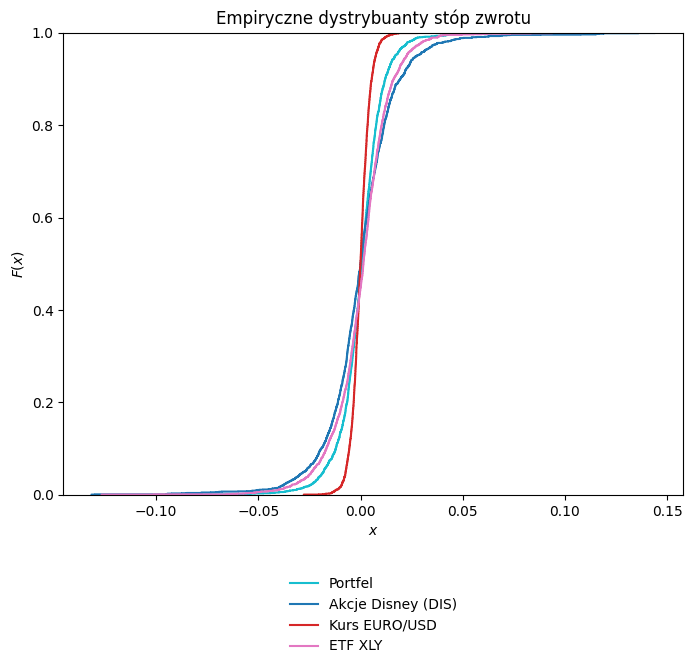

In [53]:
plt.figure(figsize=(8, 6))
sns.ecdfplot(data = Wallet, label = "Portfel", color = "C9")
sns.ecdfplot(data = Disney_clean_2, label = "Akcje Disney (DIS)", color = "C0")
sns.ecdfplot(data = Currency_clean_2, label = "Kurs EURO/USD", color = "C3")
sns.ecdfplot(data = Consumer_clean_2, label = "ETF XLY", color = "C6")
plt.title("Empiryczne dystrybuanty stóp zwrotu")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15))

Zestawienie portfela z jego pojedynczymi akcjami udowadnia, że skonstruowaliśmy instrument, który zarabia najefektywniej (najwyższa średnia w zestawieniu), niwelując przy tym ryzyko strat o 40% względem samej akcji Disneya (kwantyl 1%). To świadczy o udanej optymalizacji portfelowej: ograniczyliśmy rynkowe ryzyko do minimum, zachowując przy tym potencjał do zarabiania.

# 3. Ryzyko ekstremalne

W celu analizy ryzyka ekstremalnego dla wybranej zmiennej ryzyka zastosowano podejście oparte na teorii wartości ekstremalnych (EVT). W przeciwieństwie do wcześniejszych analiz, które uwzględniały cały rozkład zmiennej, w tym przypadku skupiono się wyłącznie na jego ogonie, czyli obserwacjach odpowiadających za największe straty.
Do modelowania wykorzystano metodę POT (Peaks Over Threshold), polegającą na analizie przekroczeń ponad ustalony wysoki próg. Zgodnie z teorią EVT, rozkład nadwyżek ponad próg może być aproksymowany rozkładem uogólnionym Pareto (GPD).
Jako zmienną ryzyka wybrano dzienne stopy zwrotu akcji spółki Disney, które następnie przekształcono do postaci strat. Za próg ekstremalności przyjęto wysoki kwantyl rozkładu strat, co pozwoliło wyodrębnić najbardziej ekstremalne obserwacje i przeprowadzić ich szczegółową analizę.

Liczba obserwacji: 2008
Próg u: 0.027405
Liczba przekroczeń: 101
Udział przekroczeń: 0.0503
Oszacowane parametry GPD:
xi (shape) = 0.2943
beta (scale) = 0.011579


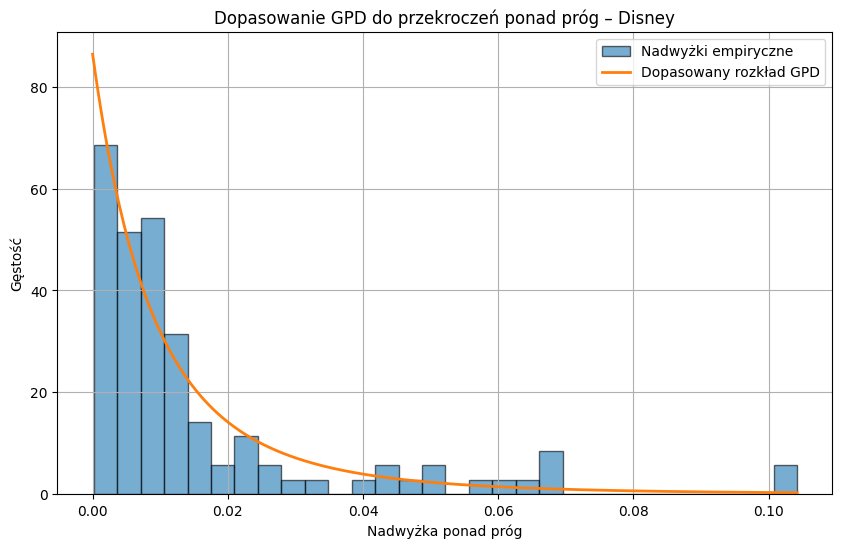

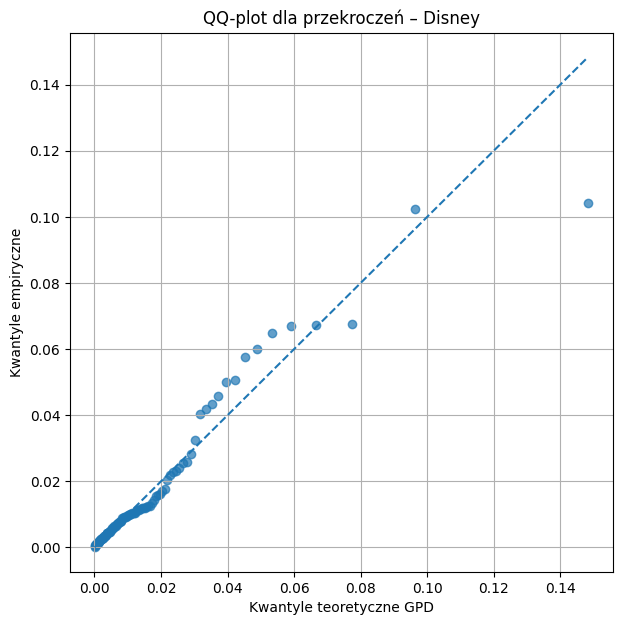

Ekstremalny VaR(99.00%) = 0.051353
Ekstremalny ES(99.00%)  = 0.077749


In [54]:

# 1. Wybór zmiennej ryzyka
# używamy dziennych stóp zwrotu Disney
r_disney = pd.Series(Disney).pct_change().dropna()

# przechodzimy na straty:
# duża dodatnia wartość = duża strata
losses = -r_disney

# 2. Ustalenie progu
# przykładowo 95% kwantyl strat
u = np.quantile(losses, 0.95)

# przekroczenia ponad próg
exceedances = losses[losses > u] - u

print("Liczba obserwacji:", len(losses))
print("Próg u:", round(u, 6))
print("Liczba przekroczeń:", len(exceedances))
print("Udział przekroczeń:", round(len(exceedances)/len(losses), 4))

# 3. Dopasowanie rozkładu GPD
# loc ustawiamy na 0, bo modelujemy nadwyżki ponad próg
xi, loc, beta = stats.genpareto.fit(exceedances, floc=0)

print("Oszacowane parametry GPD:")
print("xi (shape) =", round(xi, 4))
print("beta (scale) =", round(beta, 6))

# 4. Wykres histogramu i dopasowanej gęstości
x = np.linspace(0, exceedances.max(), 500)
gpd_pdf = stats.genpareto.pdf(x, c=xi, loc=0, scale=beta)

plt.figure(figsize=(10,6))
plt.hist(exceedances, bins=30, density=True, alpha=0.6, edgecolor='black', label='Nadwyżki empiryczne')
plt.plot(x, gpd_pdf, linewidth=2, label='Dopasowany rozkład GPD')
plt.title("Dopasowanie GPD do przekroczeń ponad próg – Disney")
plt.xlabel("Nadwyżka ponad próg")
plt.ylabel("Gęstość")
plt.legend()
plt.grid(True)
plt.show()

# 5. QQ-plot dla jakości dopasowania
p = (np.arange(1, len(exceedances)+1) - 0.5) / len(exceedances)
theoretical_q = stats.genpareto.ppf(p, c=xi, loc=0, scale=beta)
empirical_q = np.sort(exceedances)

plt.figure(figsize=(7,7))
plt.scatter(theoretical_q, empirical_q, alpha=0.7)
plt.plot(
    [min(theoretical_q.min(), empirical_q.min()), max(theoretical_q.max(), empirical_q.max())],
    [min(theoretical_q.min(), empirical_q.min()), max(theoretical_q.max(), empirical_q.max())],
    linestyle='--'
)
plt.title("QQ-plot dla przekroczeń – Disney")
plt.xlabel("Kwantyle teoretyczne GPD")
plt.ylabel("Kwantyle empiryczne")
plt.grid(True)
plt.show()

# 6. Ekstremalny VaR i ES z modelu POT
n = len(losses)
nu = len(exceedances)
p_u = nu / n   # częstość przekroczeń progu

# poziom ufności
alpha = 0.99

# VaR dla strat przy użyciu GPD
if abs(xi) > 1e-8:
    VaR_alpha = u + (beta / xi) * (((1 - alpha) / p_u) ** (-xi) - 1)
else:
    VaR_alpha = u + beta * np.log(p_u / (1 - alpha))

# ES istnieje dla xi < 1
if xi < 1:
    ES_alpha = (VaR_alpha + beta - xi * u) / (1 - xi)
else:
    ES_alpha = np.nan

print(f"Ekstremalny VaR({alpha:.2%}) =", round(VaR_alpha, 6))
print(f"Ekstremalny ES({alpha:.2%})  =", round(ES_alpha, 6))

Rozkład strat ma ciężki ogon (ξ > 0), co oznacza, że duże straty występują częściej.
W skrajnych przypadkach straty mogą przekraczać 5%, a średnio sięgać około 8%.

# 4. Backtesting
Backtesting służy do sprawdzenia, czy wcześniej wyznaczona miara ryzyka rzeczywiście dobrze opisuje zachowanie danych. W przypadku VaR 5% analizujemy dolny kwantyl rzędu 0,05 rozkładu stóp zwrotu, czyli próg wyznaczający najgorsze 5% obserwacji. Pozwala to ocenić, czy model poprawnie odwzorowuje częstość występowania skrajnie niekorzystnych zdarzeń.


Backtesting dla: Disney
Liczba obserwacji testowych: 1758
Liczba przekroczeń VaR: 91
Udział przekroczeń: 0.0518
Oczekiwany udział przekroczeń: 0.0500
Różnica: 0.0018
Wniosek: model działa dość dobrze.


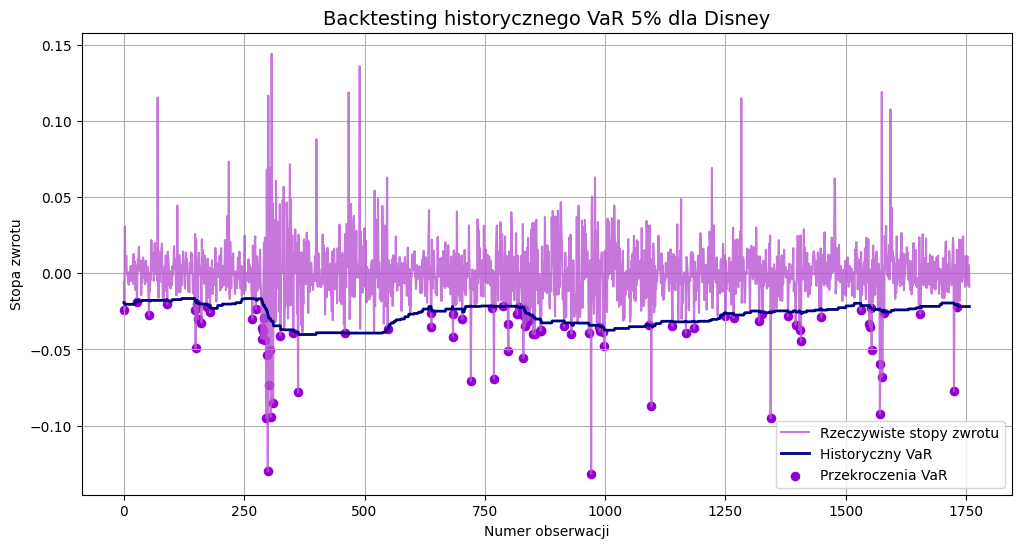


Backtesting dla: Wallet
Liczba obserwacji testowych: 1758
Liczba przekroczeń VaR: 95
Udział przekroczeń: 0.0540
Oczekiwany udział przekroczeń: 0.0500
Różnica: 0.0040
Wniosek: model działa dość dobrze.


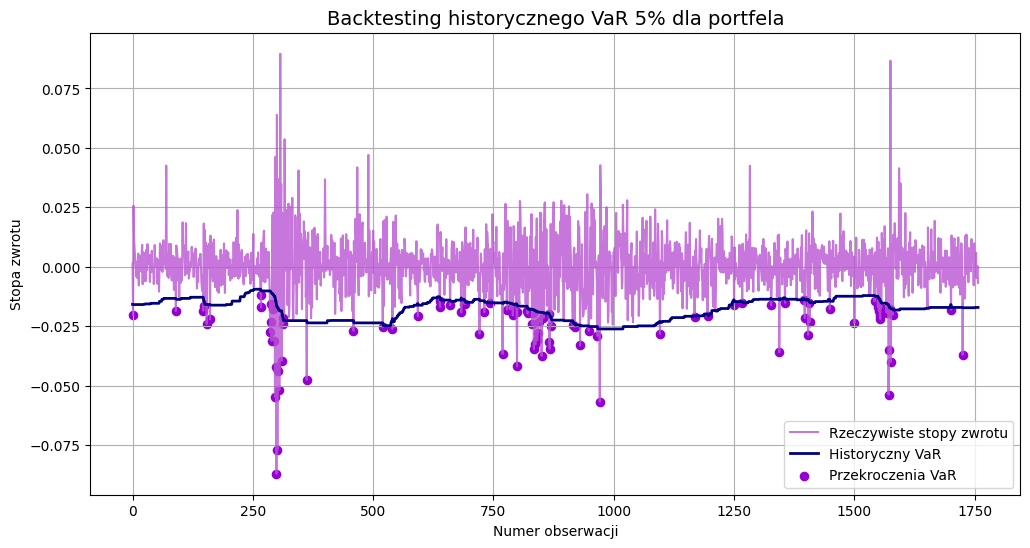

In [57]:
def historical_var_backtest(series, alpha=0.05, window=250):
    series = pd.Series(series).dropna().reset_index(drop=True)

    # Listy do przechowania:
    # - prognozowanego VaR
    # - rzeczywiście zaobserwowanych stóp zwrotu
    # - informacji, czy nastąpiło przekroczenie VaR
    var_forecasts = []
    realized = []
    exceedances = []

    # dla każdej obserwacji od momentu zebrania pierwszych 250 danych wyznaczamy VaR na podstawie poprzednich wartości
    for i in range(window, len(series)):
        train_window = series.iloc[i - window:i]
        var_t = np.quantile(train_window, alpha)
        real_t = series.iloc[i]
        exc_t = real_t < var_t  # przekroczenie VaR zachodzi wtedy, gdy rzeczywista stopa zwrotu spada poniżej wyznaczonego poziomu VaR

        var_forecasts.append(var_t)
        realized.append(real_t)
        exceedances.append(exc_t)

    results = pd.DataFrame({
        "realized": realized,
        "VaR": var_forecasts,
        "exceedance": exceedances
    })

    return results


def summarize_backtest(results, alpha=0.05, name="Zmienne"):
    # liczba obserwacji testowych
    n = len(results)

    # liczba przekroczeń VaR
    n_exc = results["exceedance"].sum()

    # empiryczny udział przekroczeń
    exc_rate = n_exc / n

    print(f"\nBacktesting dla: {name}")
    print(f"Liczba obserwacji testowych: {n}")
    print(f"Liczba przekroczeń VaR: {n_exc}")
    print(f"Udział przekroczeń: {exc_rate:.4f}")
    print(f"Oczekiwany udział przekroczeń: {alpha:.4f}")
    print(f"Różnica: {exc_rate - alpha:.4f}")

    # jeśli udział przekroczeń jest bliski alpha, to model dobrze odzwierciedla poziom ryzyka
    if abs(exc_rate - alpha) < 0.02:
        print("Wniosek: model działa dość dobrze.")
    elif exc_rate > alpha:
        # zbyt dużo przekroczeń oznacza, że VaR był zbyt łagodny, czyli model zaniża ryzyko
        print("Wniosek: model zaniża ryzyko (za dużo przekroczeń).")
    else:
        # zbyt mało przekroczeń oznacza, że VaR był zbyt konserwatywny, czyli model zawyża ryzyko
        print("Wniosek: model zawyża ryzyko (za mało przekroczeń).")


def plot_backtest(results, title="Backtesting VaR"):
    plt.figure(figsize=(12, 6))

    # wykres rzeczywistych stóp zwrotu
    plt.plot(results.index, results["realized"], label="Rzeczywiste stopy zwrotu", alpha=0.8, color ='mediumorchid')

    # wykres prognozowanego poziomu VaR
    plt.plot(results.index, results["VaR"], label="Historyczny VaR", linewidth=2, color='navy')

    # wyznaczenie indeksów obserwacji, dla których nastąpiło przekroczenie VaR
    exc_idx = results.index[results["exceedance"]]

    plt.scatter(
        exc_idx,
        results.loc[exc_idx, "realized"],
        label="Przekroczenia VaR",
        marker="o",
        s=35,
        color="darkviolet"
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Numer obserwacji")
    plt.ylabel("Stopa zwrotu")
    plt.grid(True)
    plt.legend()
    plt.show()


# Parametry backtestingu:
# alpha = 0.05 oznacza analizę VaR 5%, czyli kwantyla rzędu 0.05
# window = 250 oznacza, że VaR w każdym kroku wyznaczamy na podstawie ostatnich 250 obserwacji historycznych
alpha = 0.05
window = 250

# 1. Backtesting dla spółki Disney
disney_bt = historical_var_backtest(Disney_clean_2, alpha=alpha, window=window)
summarize_backtest(disney_bt, alpha=alpha, name="Disney")
plot_backtest(disney_bt, title="Backtesting historycznego VaR 5% dla Disney")

# 2. Backtesting dla portfela 
wallet_bt = historical_var_backtest(Wallet, alpha=alpha, window=window)
summarize_backtest(wallet_bt, alpha=alpha, name="Wallet")
plot_backtest(wallet_bt, title="Backtesting historycznego VaR 5% dla portfela")

Dla spółki Disney różnica była bardzo mała i wyniosła 0.0018. Oznacza to, że model historycznego VaR dla tej zmiennej bardzo dobrze odzwierciedlał faktyczne ryzyko.

Dla portfela różnica wynosi 0.0040. Można więc uznać, że model również dla portfela działa poprawnie, choć w porównaniu ze spółką Disney nieznacznie częściej pojawiały się przekroczenia, co może sugerować lekkie zaniżanie ryzyka portfela.

Przeprowadzony backtesting pokazuje, że w obu analizowanych przypadkach model historycznego VaR 5% działa dość dobrze, ponieważ rzeczywista częstość przekroczeń jest bardzo zbliżona do poziomu teoretycznego. Portfel wypadł nieco gorzej, ponieważ jego ryzyko jest bardziej złożone niż ryzyko jednej spółki, które zależy nie tylko od pojedynczych stóp zwrotu, ale też od współzależności między składnikami portfela.